In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from generator import Generator
from PIL import Image


/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gen = Generator(fov=10 , telescope='euclid')

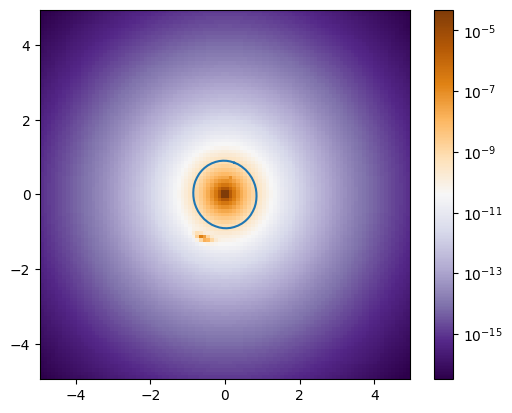

In [3]:
model = gen.get_model()
critical_curves = gen.get_critical_curves()

plt.imshow(model, origin='lower', cmap="PuOr_r", extent=gen.pixel_grid.extent, norm='log')
plt.colorbar()

for curve in critical_curves:
    plt.plot(curve[:,0], curve[:,1])
plt.show()

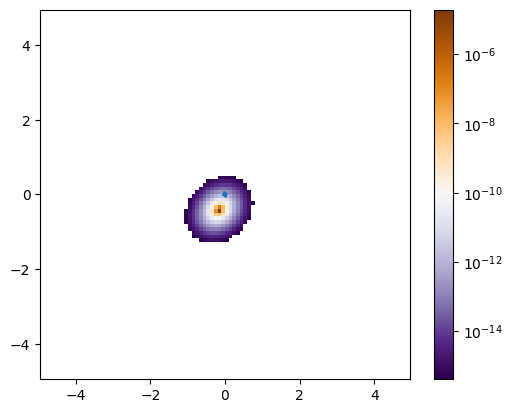

In [4]:
source = gen.get_source()
caustics = gen.get_caustics()

plt.imshow(source, origin='lower', cmap="PuOr_r", extent=gen.pixel_grid.extent, norm='log')
plt.colorbar()

for curve in caustics:
    plt.plot(curve[:,0], curve[:,1])
plt.show()

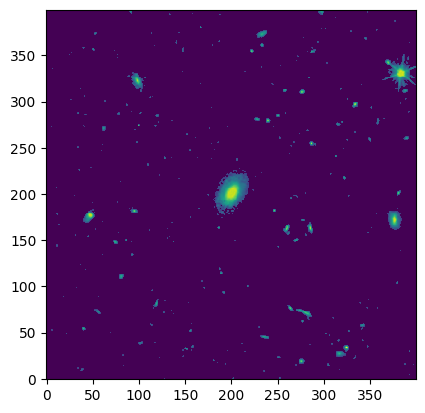

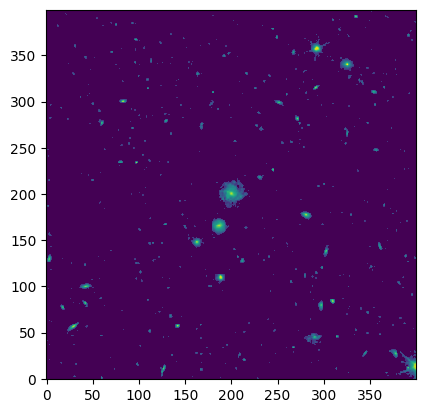

In [5]:
img1 = np.load("data/euclid_deep_VIS1.npy")
img2 = np.load("data/euclid_deep_VIS2.npy")

plt.imshow(img1)
plt.show()

plt.imshow(img2)
plt.show()

In [6]:
gen = Generator(fov=15, lens_img=img1, source_img=img2, telescope='euclid')
model = gen.get_model()
sim = gen.get_simulation()

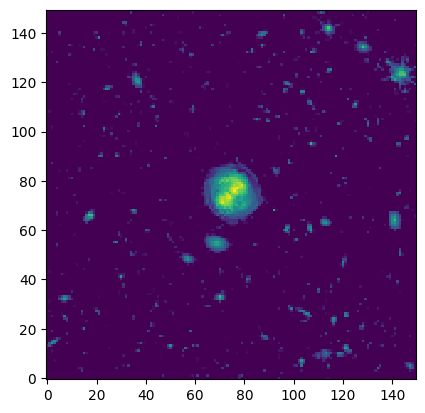

In [7]:
plt.imshow(model)
plt.show()

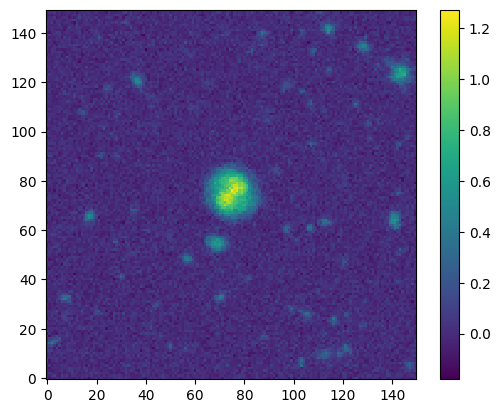

In [8]:
plt.imshow(sim)
plt.colorbar()
plt.show()

In [9]:
import numpy as np

from dspl_generator import DSPLGenerator

In [10]:
gen = DSPLGenerator(15)
gen.n_models("modelled_images/")

In [11]:
model = gen.get_model()

print(np.sum(model))

18.62948


In [12]:
import numpyro
import numpyro.distributions as dist
import jax

import matplotlib.pyplot as plt

In [30]:
key = jax.random.PRNGKey(0)
N=1000
X = dist.TruncatedNormal(loc=1.0, scale=0.2, low=0.0, high=1.0).sample(key, sample_shape=(N,))

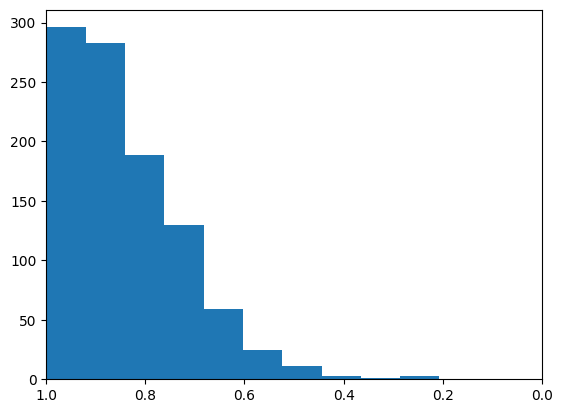

In [31]:
plt.hist(X)

plt.xlim(1.0, 0.0)

plt.show()